###### ---
# Clustering
- Grouping Similar Data Together

    ## Clustering Algorithms
    - K Means Clustering
    - Heirarchical Clustering
    - Density Based Clustering
---

-----------
# K Means Clustering
<img align = 'left' src = 'KMC.jpg' style = 'width:600px; hieght:400px' />

---
## K Means algorithm
- Step1 : Select a value of k (Number of Clusters)
- Step2 : Assign a cluster to each data point randomly
- Step3 : Calculate Centroids for each Cluster
- Step4 : Assign each data point to its closest centroid
- Step5 : Back to step3
---

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import style
style.use('ggplot')

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [30]:
df = pd.read_csv('Mall_customers.csv')
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [32]:
df.duplicated().sum()

0

In [33]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

<AxesSubplot:ylabel='Annual Income (k$)'>

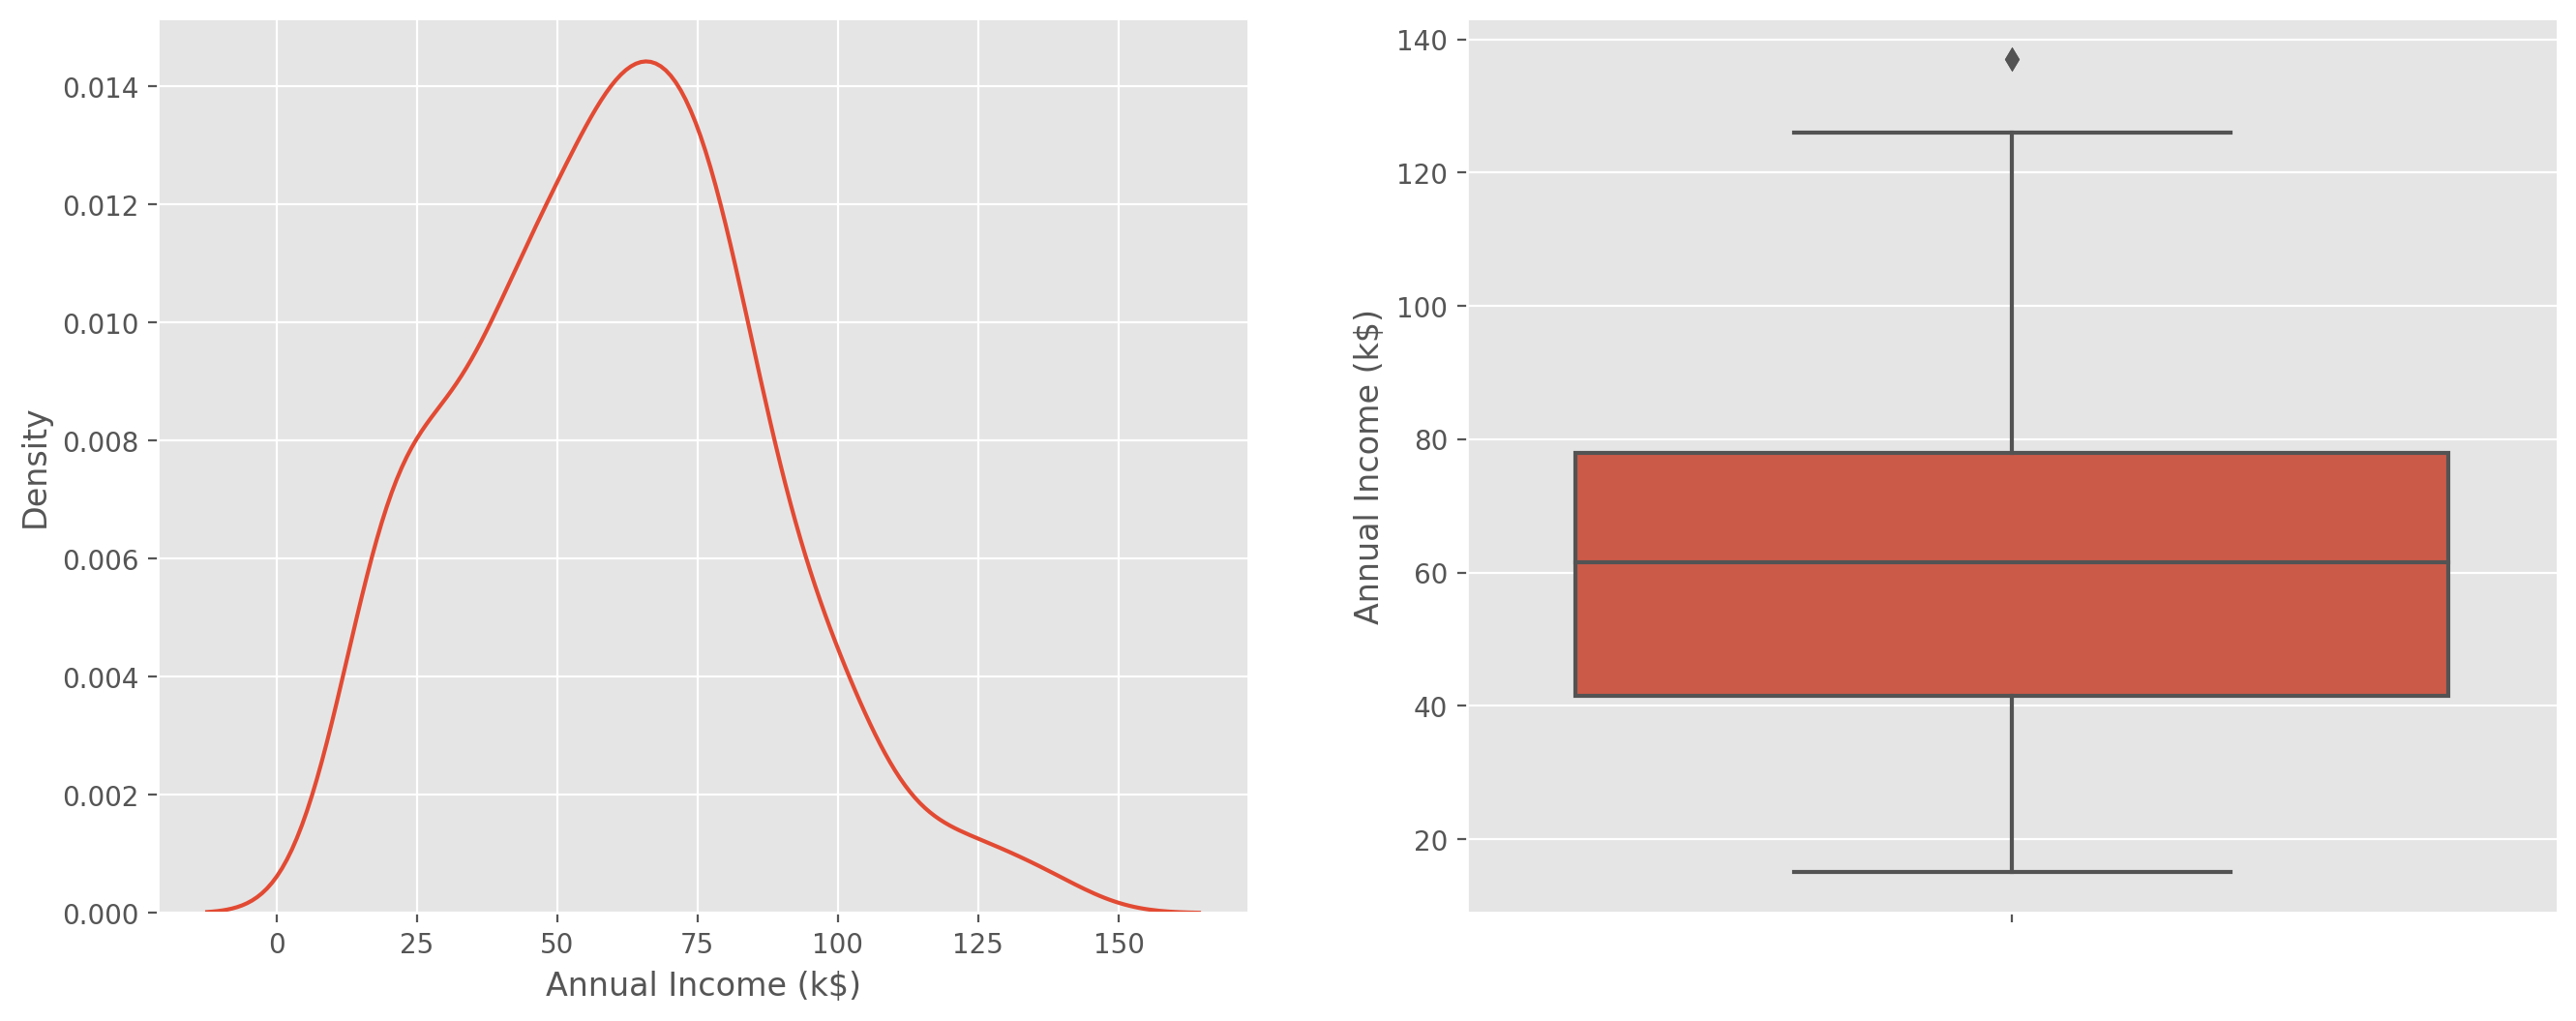

In [34]:
plt.figure(figsize = (16,6), dpi = 200)
plt.subplot(1,2,1)
sns.distplot(df['Annual Income (k$)'], hist = False)
plt.subplot(1,2,2)
sns.boxplot(y = df['Annual Income (k$)'])

<AxesSubplot:ylabel='Spending Score (1-100)'>

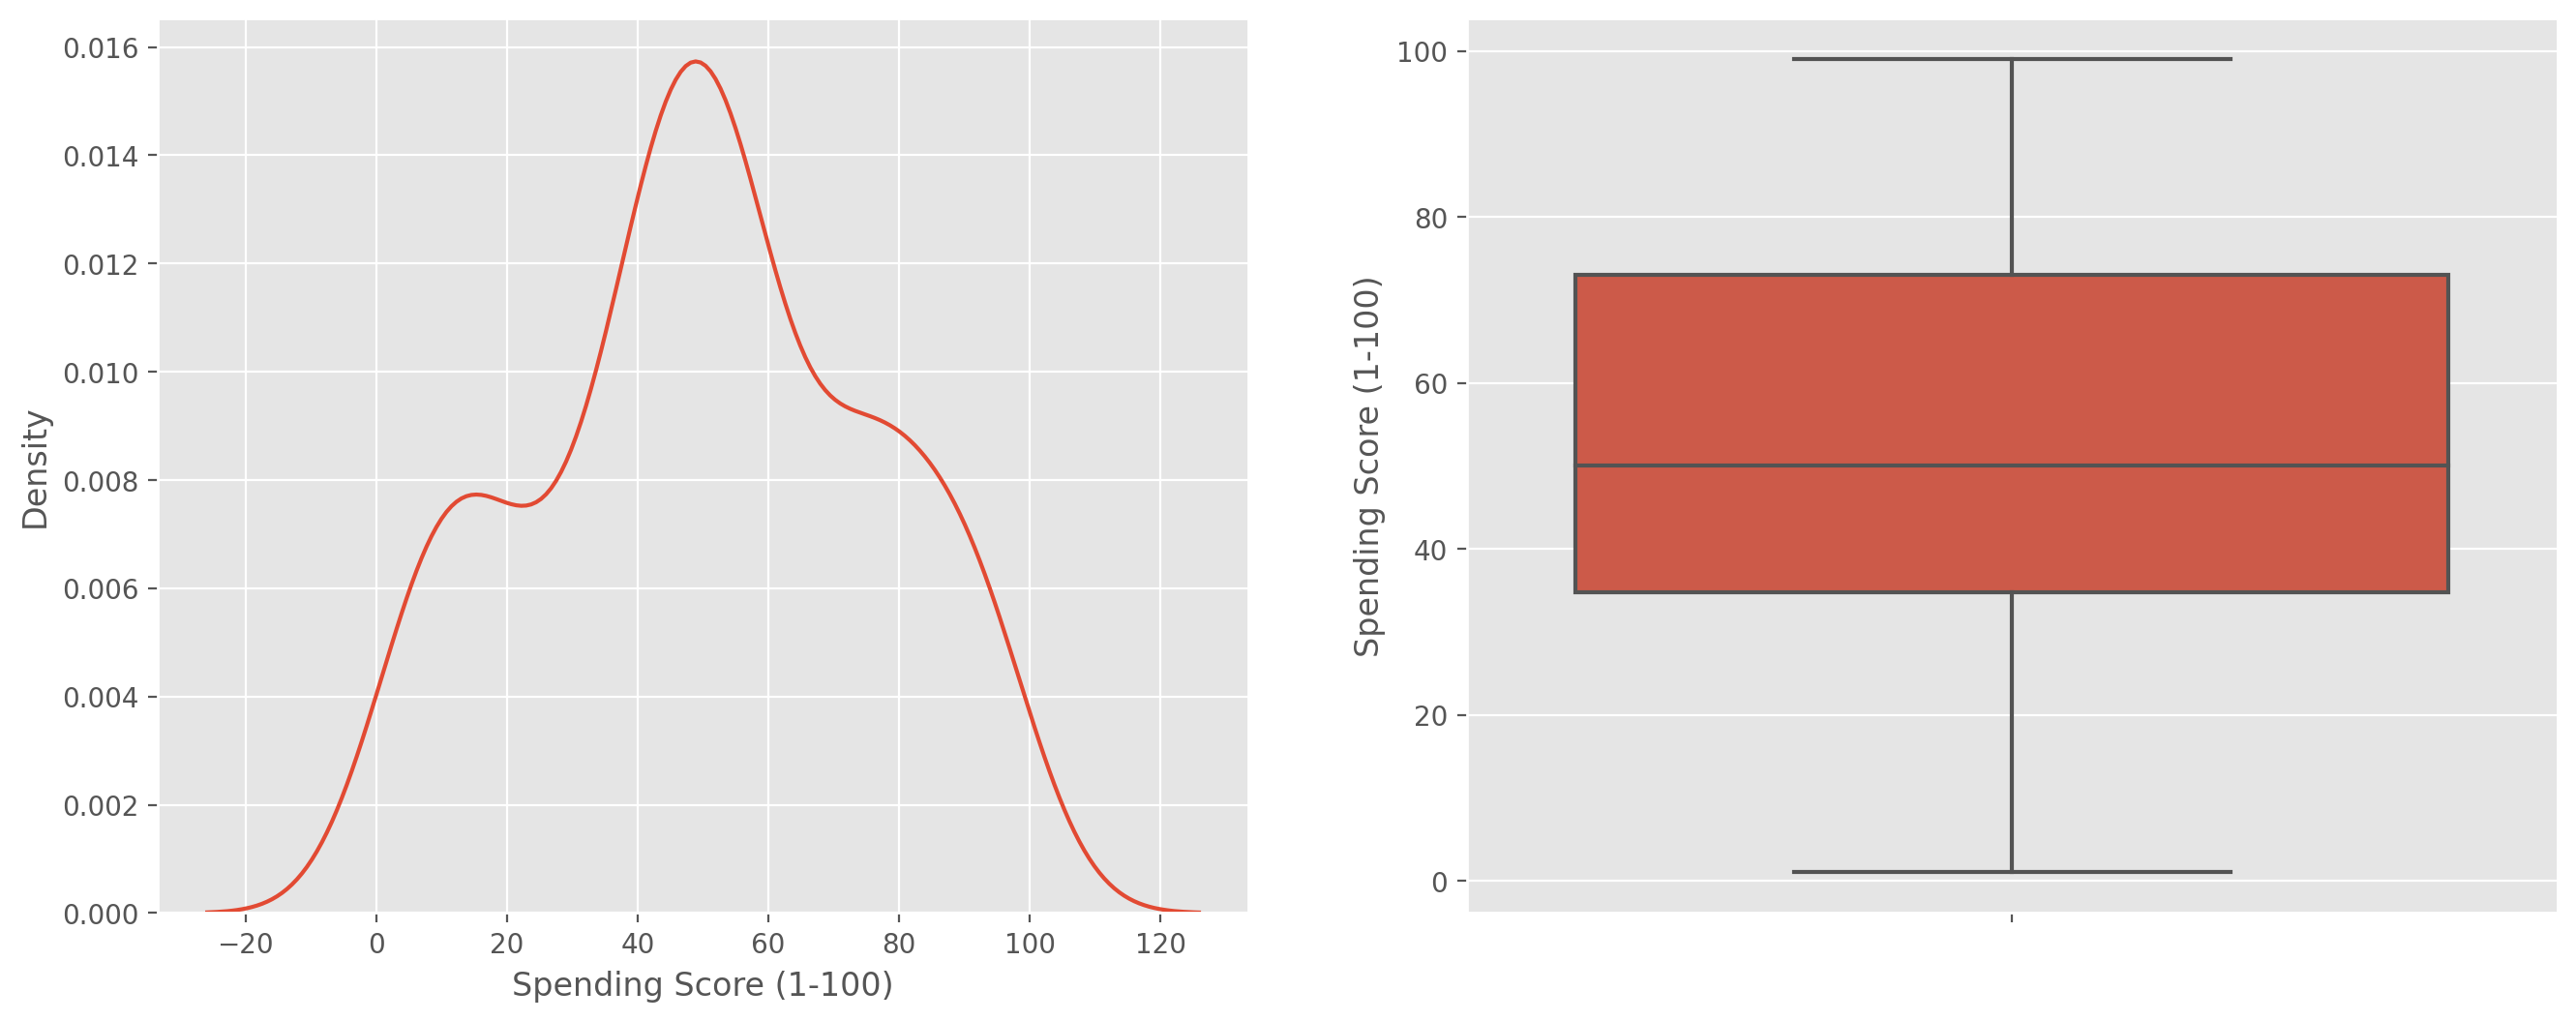

In [35]:
plt.figure(figsize = (16,6), dpi = 200)
plt.subplot(1,2,1)
sns.distplot(df['Spending Score (1-100)'], hist = False)
plt.subplot(1,2,2)
sns.boxplot(y = df['Spending Score (1-100)'])

<AxesSubplot:xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

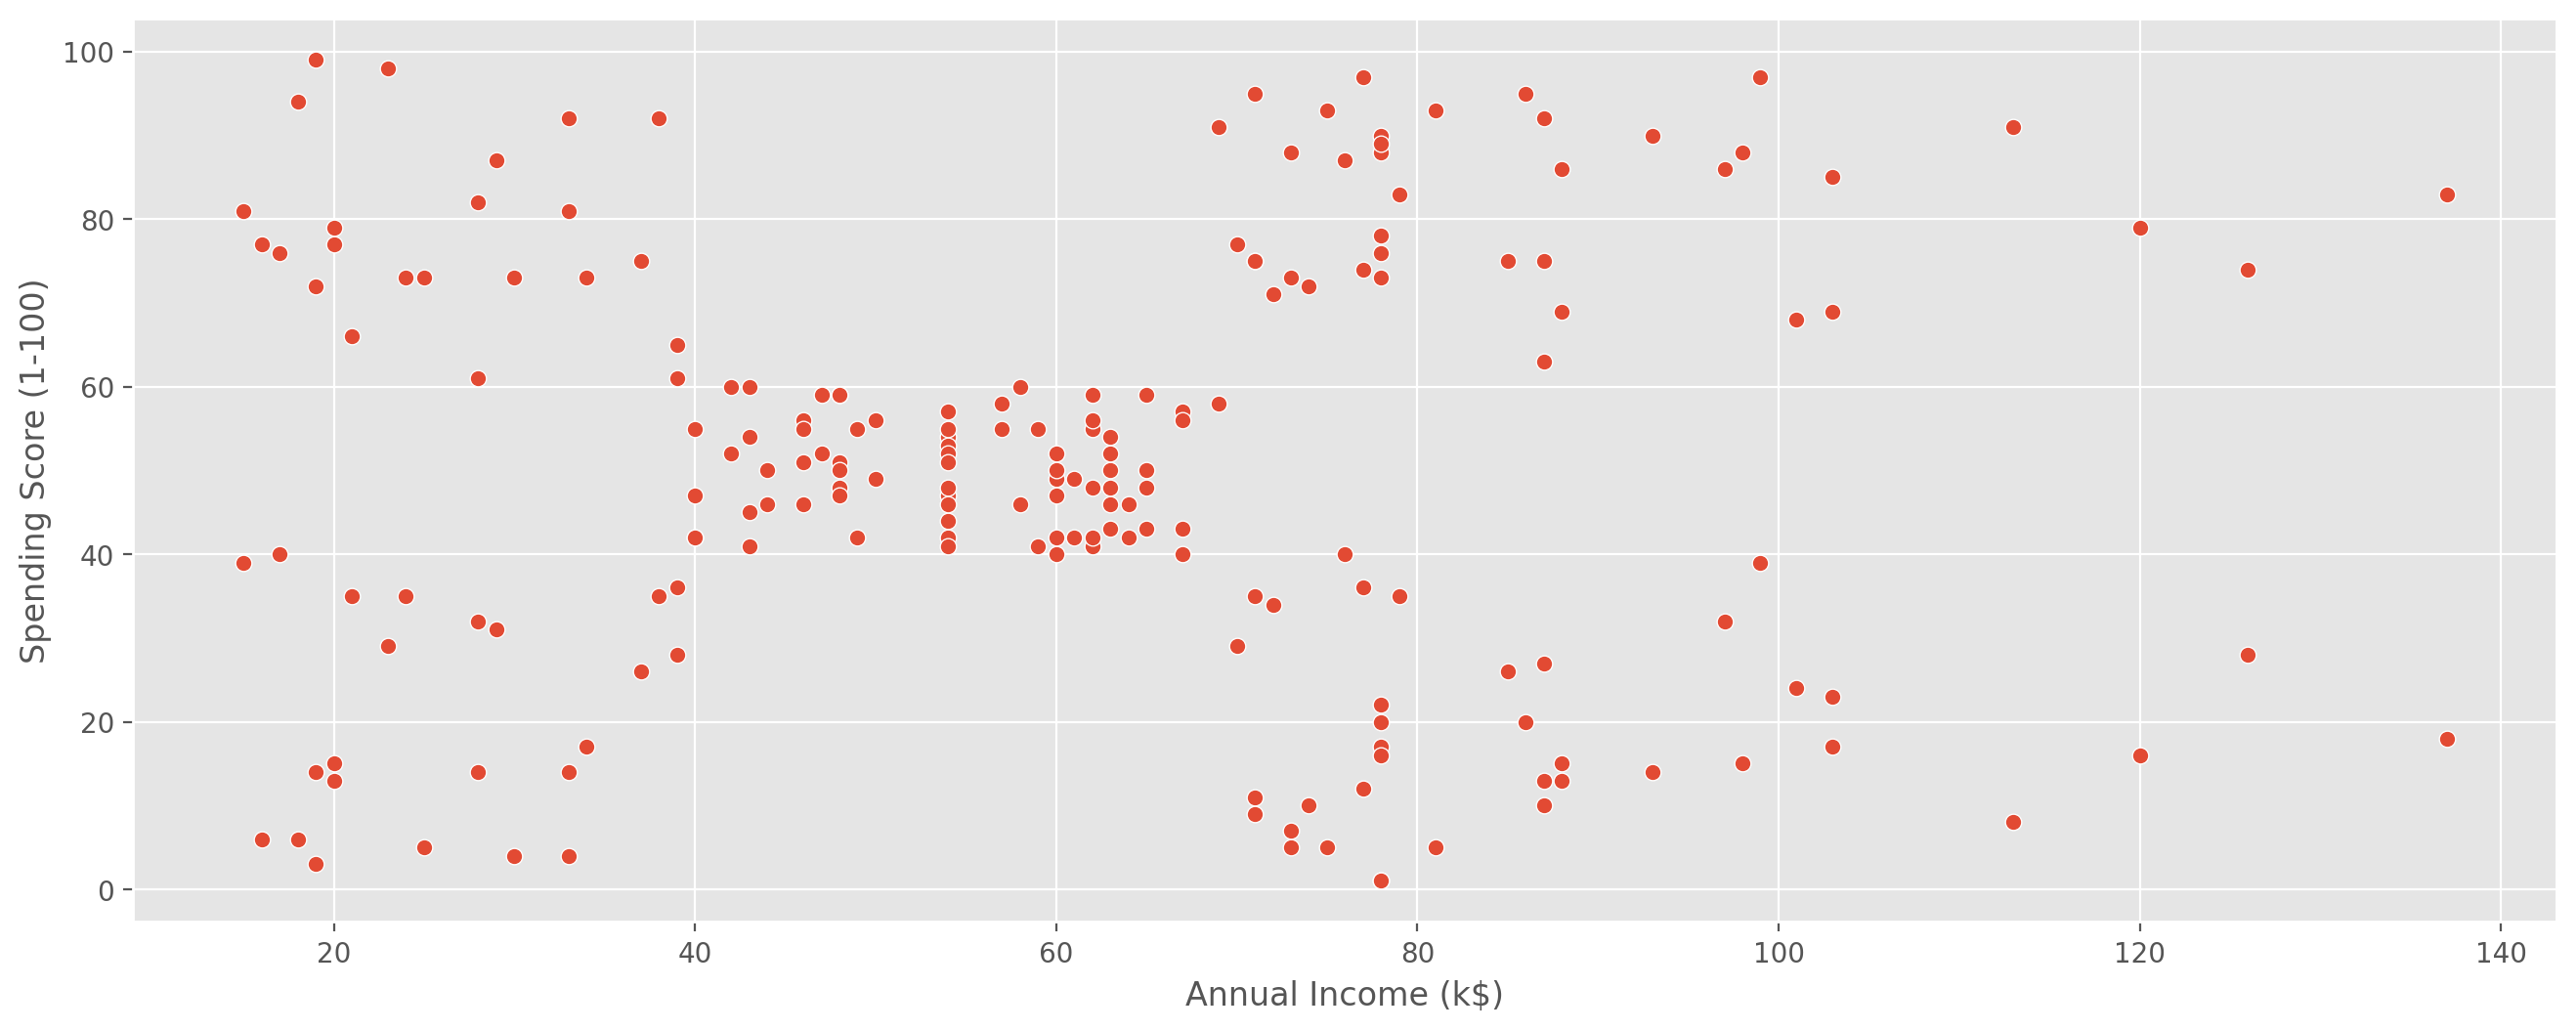

In [36]:
plt.figure(figsize = (16,6), dpi = 200)
sns.scatterplot('Annual Income (k$)', 'Spending Score (1-100)', data = df)

In [37]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
X[:5]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40]], dtype=int64)

In [38]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters = 3)
km.fit(X)

KMeans(n_clusters=3)

In [39]:
y_kmeans = km.fit_predict(X)
y_kmeans

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

In [40]:
len(y_kmeans)

200

In [41]:
km.cluster_centers_

array([[44.15447154, 49.82926829],
       [86.53846154, 82.12820513],
       [87.        , 18.63157895]])

In [42]:
km.inertia_                               # WCSS

106348.37306211119

---
## Visualizing Clusters

In [43]:
# Extracting all data points belonging to cluster 0
X[y_kmeans == 0]

array([[15, 39],
       [15, 81],
       [16,  6],
       [16, 77],
       [17, 40],
       [17, 76],
       [18,  6],
       [18, 94],
       [19,  3],
       [19, 72],
       [19, 14],
       [19, 99],
       [20, 15],
       [20, 77],
       [20, 13],
       [20, 79],
       [21, 35],
       [21, 66],
       [23, 29],
       [23, 98],
       [24, 35],
       [24, 73],
       [25,  5],
       [25, 73],
       [28, 14],
       [28, 82],
       [28, 32],
       [28, 61],
       [29, 31],
       [29, 87],
       [30,  4],
       [30, 73],
       [33,  4],
       [33, 92],
       [33, 14],
       [33, 81],
       [34, 17],
       [34, 73],
       [37, 26],
       [37, 75],
       [38, 35],
       [38, 92],
       [39, 36],
       [39, 61],
       [39, 28],
       [39, 65],
       [40, 55],
       [40, 47],
       [40, 42],
       [40, 42],
       [42, 52],
       [42, 60],
       [43, 54],
       [43, 60],
       [43, 45],
       [43, 41],
       [44, 50],
       [44, 46],
       [46, 51

In [44]:
# Extracting annual income of all data points belonging to cluster 0
X[y_kmeans == 0,0]

array([15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 19, 20, 20, 20, 20, 21,
       21, 23, 23, 24, 24, 25, 25, 28, 28, 28, 28, 29, 29, 30, 30, 33, 33,
       33, 33, 34, 34, 37, 37, 38, 38, 39, 39, 39, 39, 40, 40, 40, 40, 42,
       42, 43, 43, 43, 43, 44, 44, 46, 46, 46, 46, 47, 47, 48, 48, 48, 48,
       48, 48, 49, 49, 50, 50, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54, 54,
       54, 57, 57, 58, 58, 59, 59, 60, 60, 60, 60, 60, 60, 61, 61, 62, 62,
       62, 62, 62, 62, 63, 63, 63, 63, 63, 63, 64, 64, 65, 65, 65, 65, 67,
       67, 67, 67, 69], dtype=int64)

In [45]:
# Extracting spending score of all data points belonging to cluster 0
X[y_kmeans == 0,1]

array([39, 81,  6, 77, 40, 76,  6, 94,  3, 72, 14, 99, 15, 77, 13, 79, 35,
       66, 29, 98, 35, 73,  5, 73, 14, 82, 32, 61, 31, 87,  4, 73,  4, 92,
       14, 81, 17, 73, 26, 75, 35, 92, 36, 61, 28, 65, 55, 47, 42, 42, 52,
       60, 54, 60, 45, 41, 50, 46, 51, 46, 56, 55, 52, 59, 51, 59, 50, 48,
       59, 47, 55, 42, 49, 56, 47, 54, 53, 48, 52, 42, 51, 55, 41, 44, 57,
       46, 58, 55, 60, 46, 55, 41, 49, 40, 42, 52, 47, 50, 42, 49, 41, 48,
       59, 55, 56, 42, 50, 46, 43, 48, 52, 54, 42, 46, 48, 50, 43, 59, 43,
       57, 56, 40, 58], dtype=int64)

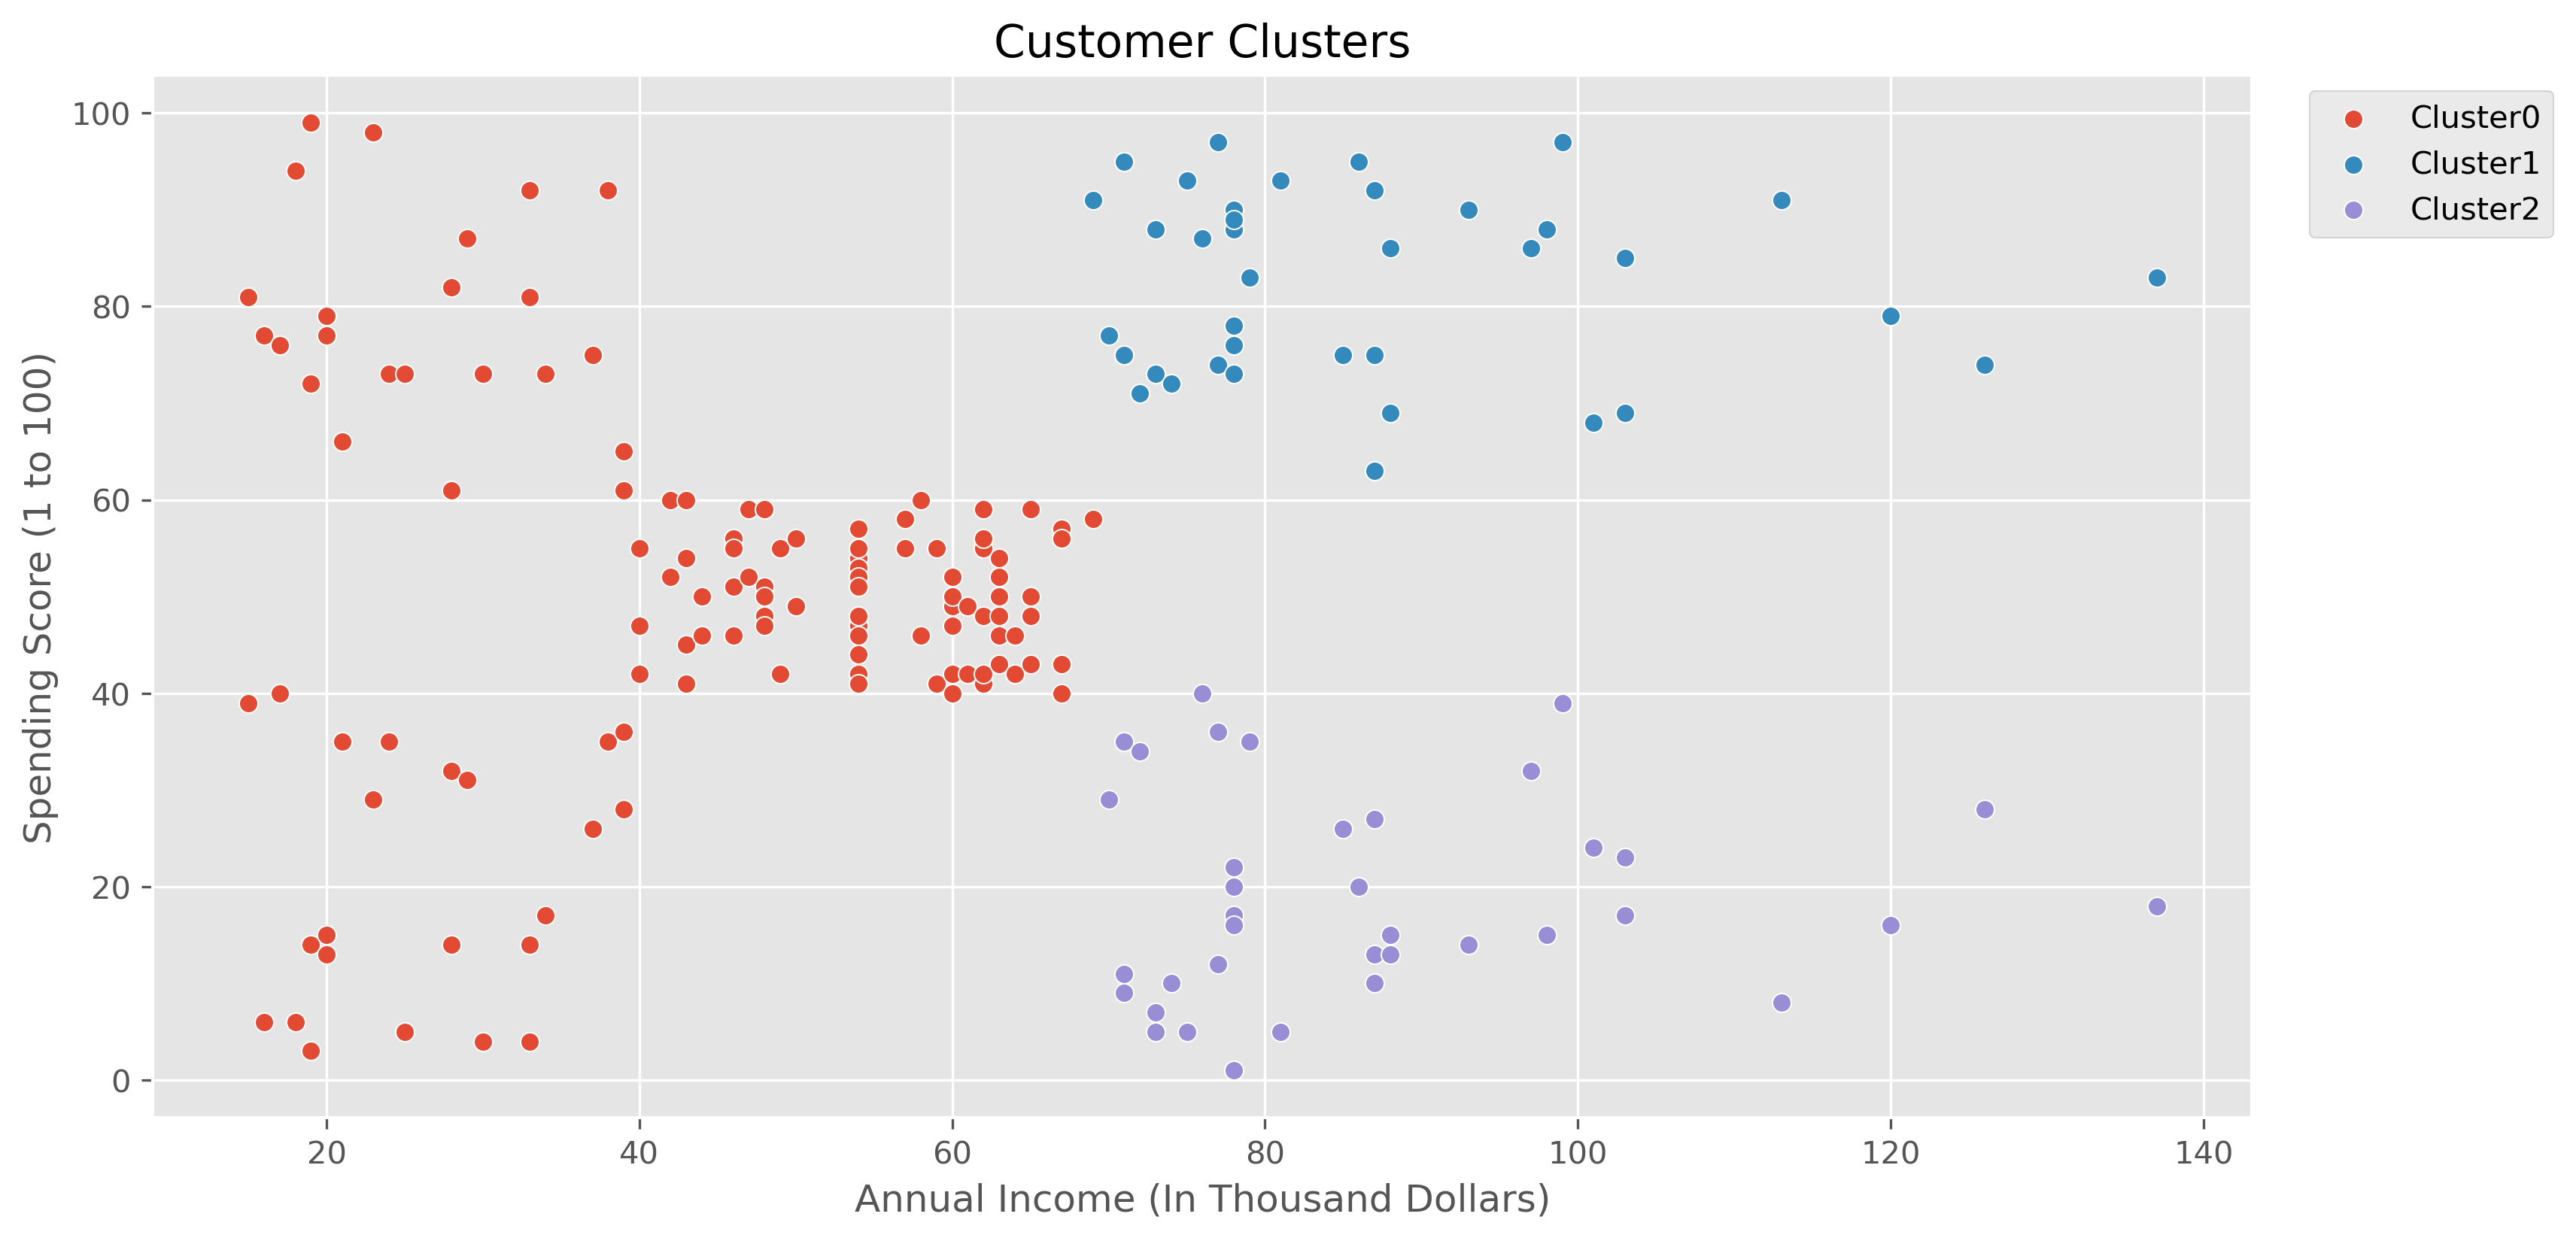

In [46]:
# Visualizing the clusters
plt.figure(figsize = (12,6), dpi = 300)
sns.scatterplot(X[y_kmeans == 0,0], X[y_kmeans == 0,1], label = 'Cluster0')
sns.scatterplot(X[y_kmeans == 1,0], X[y_kmeans == 1,1], label = 'Cluster1')
sns.scatterplot(X[y_kmeans == 2,0], X[y_kmeans == 2,1], label = 'Cluster2')

plt.title('Customer Clusters')
plt.xlabel('Annual Income (In Thousand Dollars)')
plt.ylabel('Spending Score (1 to 100)')
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

---
# Elbow Method (Finding Best Value K)
- Create a visualization having number of clusters on x axis and WCSS on y axis
- Look for a sharp elbow in the curve
- The elbow indicates that upto that point the reduction in wcss was fast but after that the rate of reduction in wcss is slow
- The value of k at which this elbow is present is best value of k

In [47]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [48]:
wcss = []
for k in range(2,21):
    km = KMeans(n_clusters = k)
    km.fit(X)
    wcss.append(km.inertia_)
    

In [49]:
wcss

[181363.595959596,
 106348.37306211119,
 73679.78903948837,
 44448.45544793371,
 37239.83554245604,
 30259.65720728547,
 25028.020475269415,
 21850.16528258563,
 20053.30040792541,
 17586.63244734051,
 16239.594305530632,
 14387.953896103896,
 13399.763522099563,
 11718.493442084231,
 11219.01680819181,
 10226.685139734707,
 9576.047731628536,
 8528.04494763754,
 7877.209060249214]

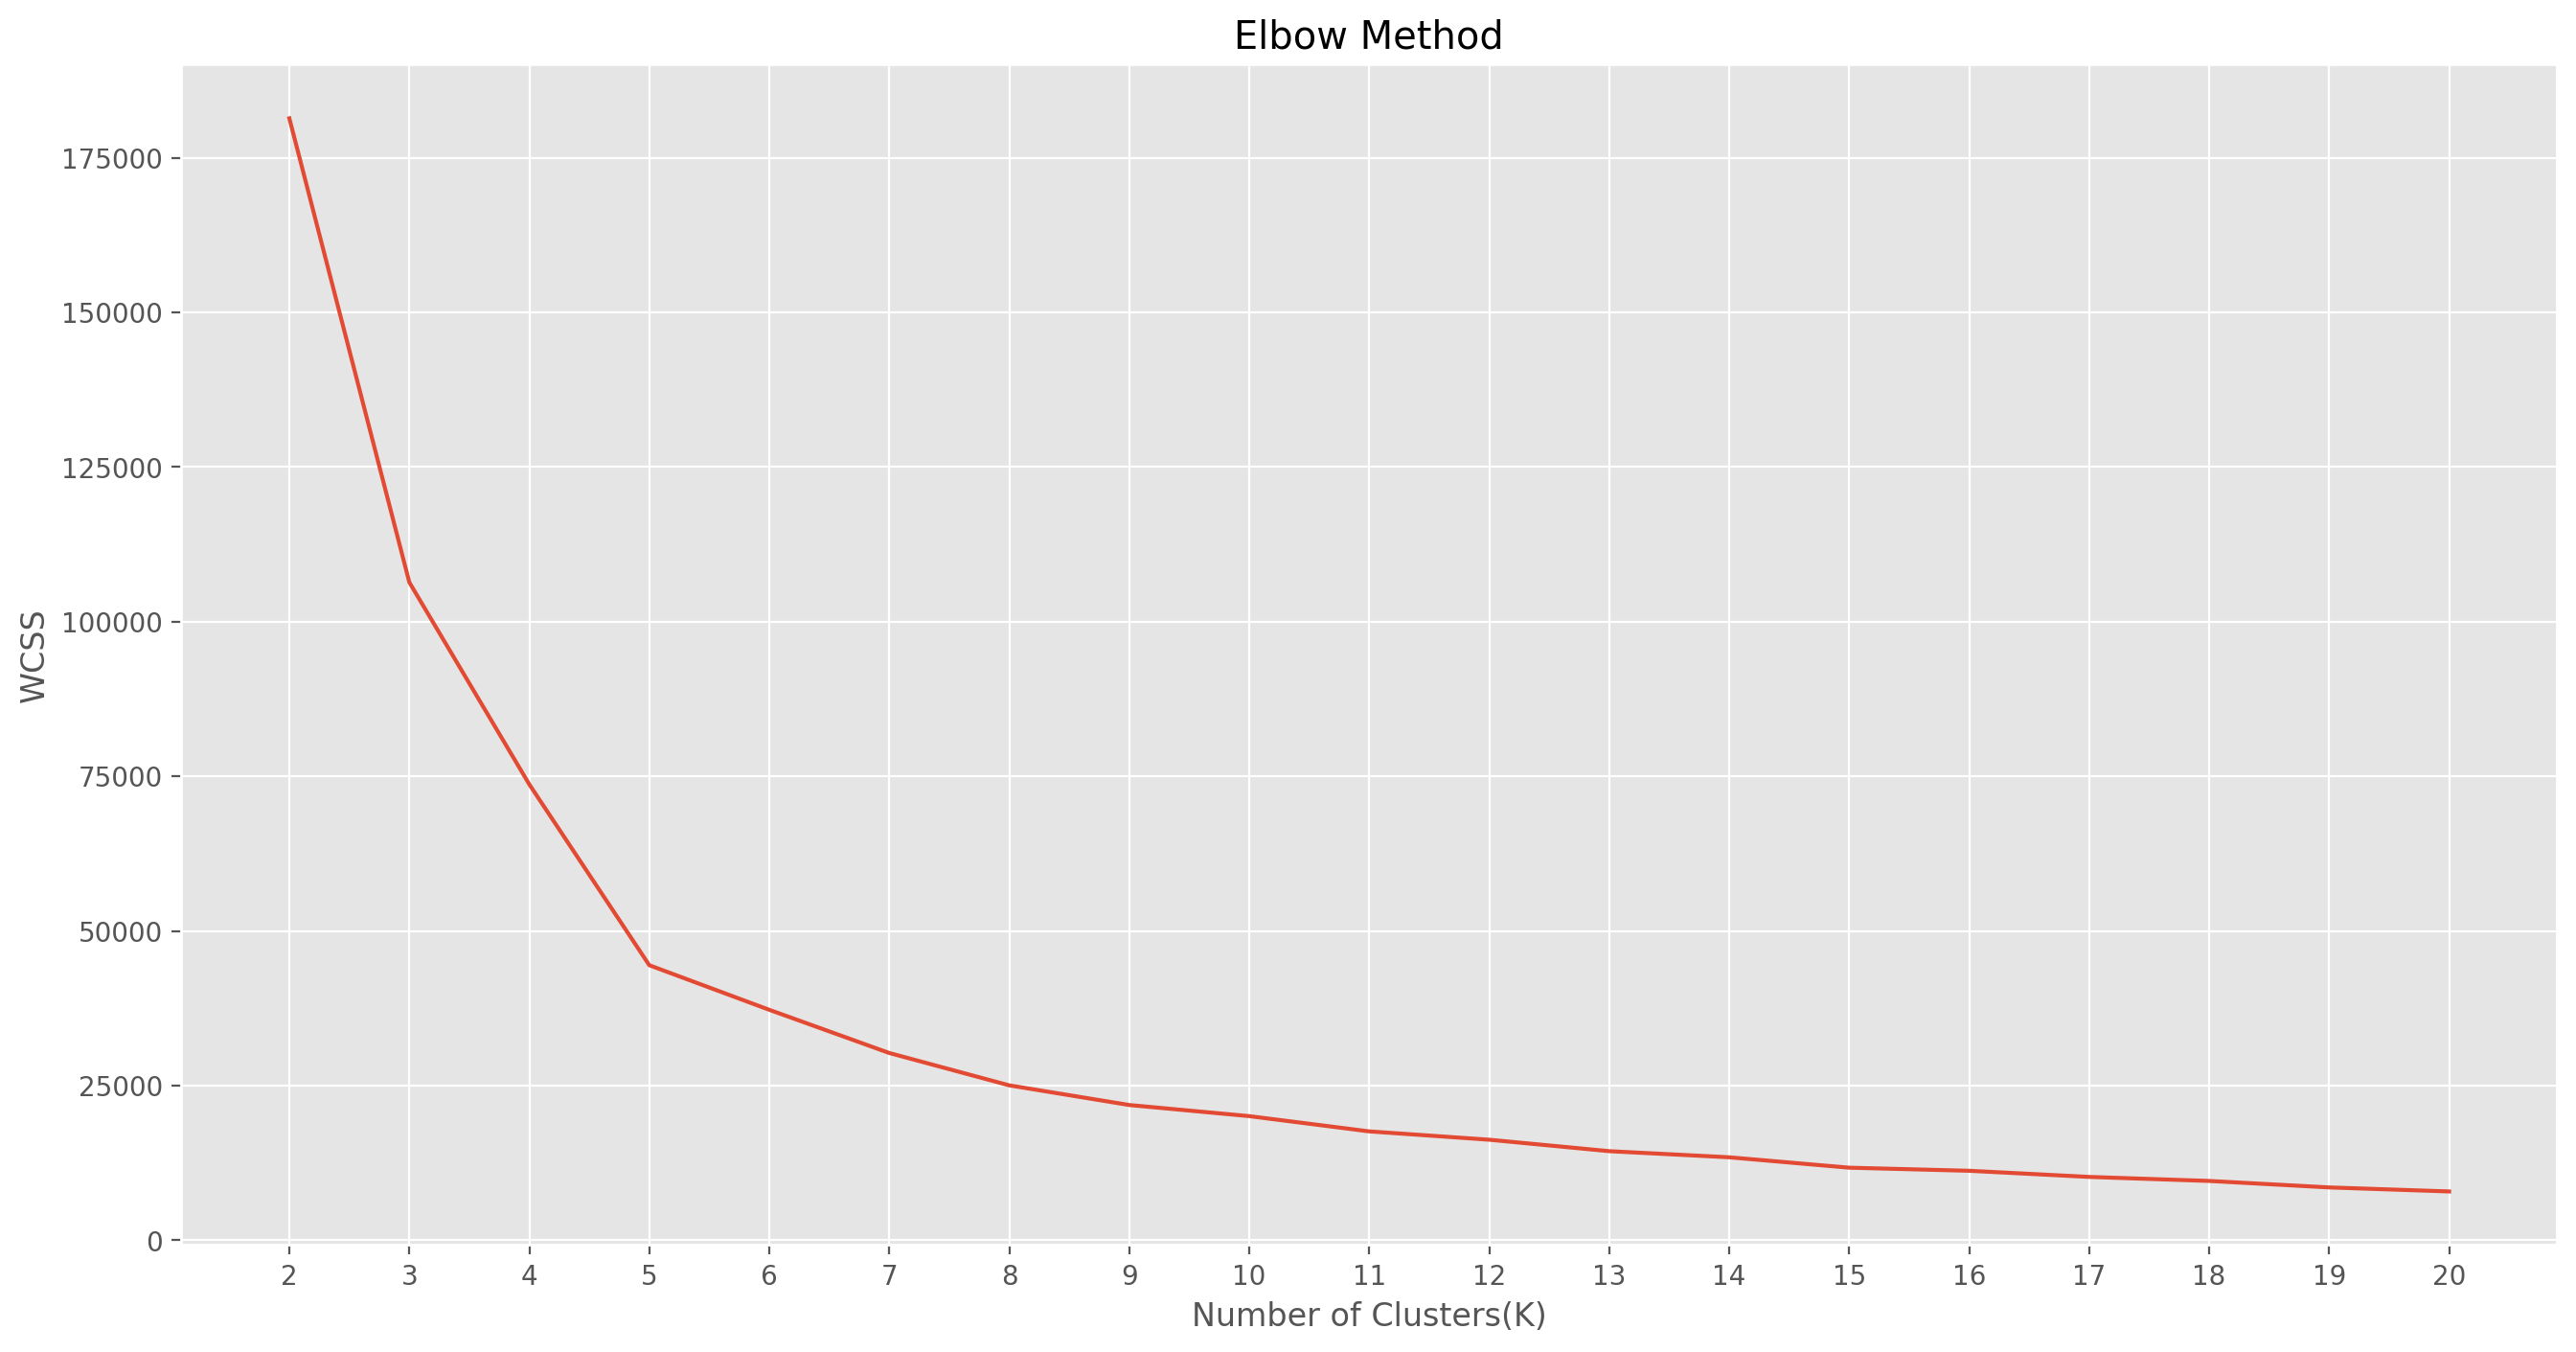

In [51]:
k = range(2,21)
plt.figure(figsize = (16,8), dpi = 200)
sns.lineplot(k, wcss)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('WCSS')
plt.xticks(k)
plt.show()

In [52]:
# Best model
km_best = KMeans(n_clusters = 5)
km_best.fit(X)

KMeans(n_clusters=5)

In [54]:
y_kmeans = km_best.fit_predict(X)
y_kmeans

array([3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 0,
       3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 4, 2, 0, 2, 4, 2, 4, 2,
       0, 2, 4, 2, 4, 2, 4, 2, 4, 2, 0, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2])

In [55]:
centroids = km_best.cluster_centers_
centroids

array([[55.2962963 , 49.51851852],
       [25.72727273, 79.36363636],
       [86.53846154, 82.12820513],
       [26.30434783, 20.91304348],
       [88.2       , 17.11428571]])

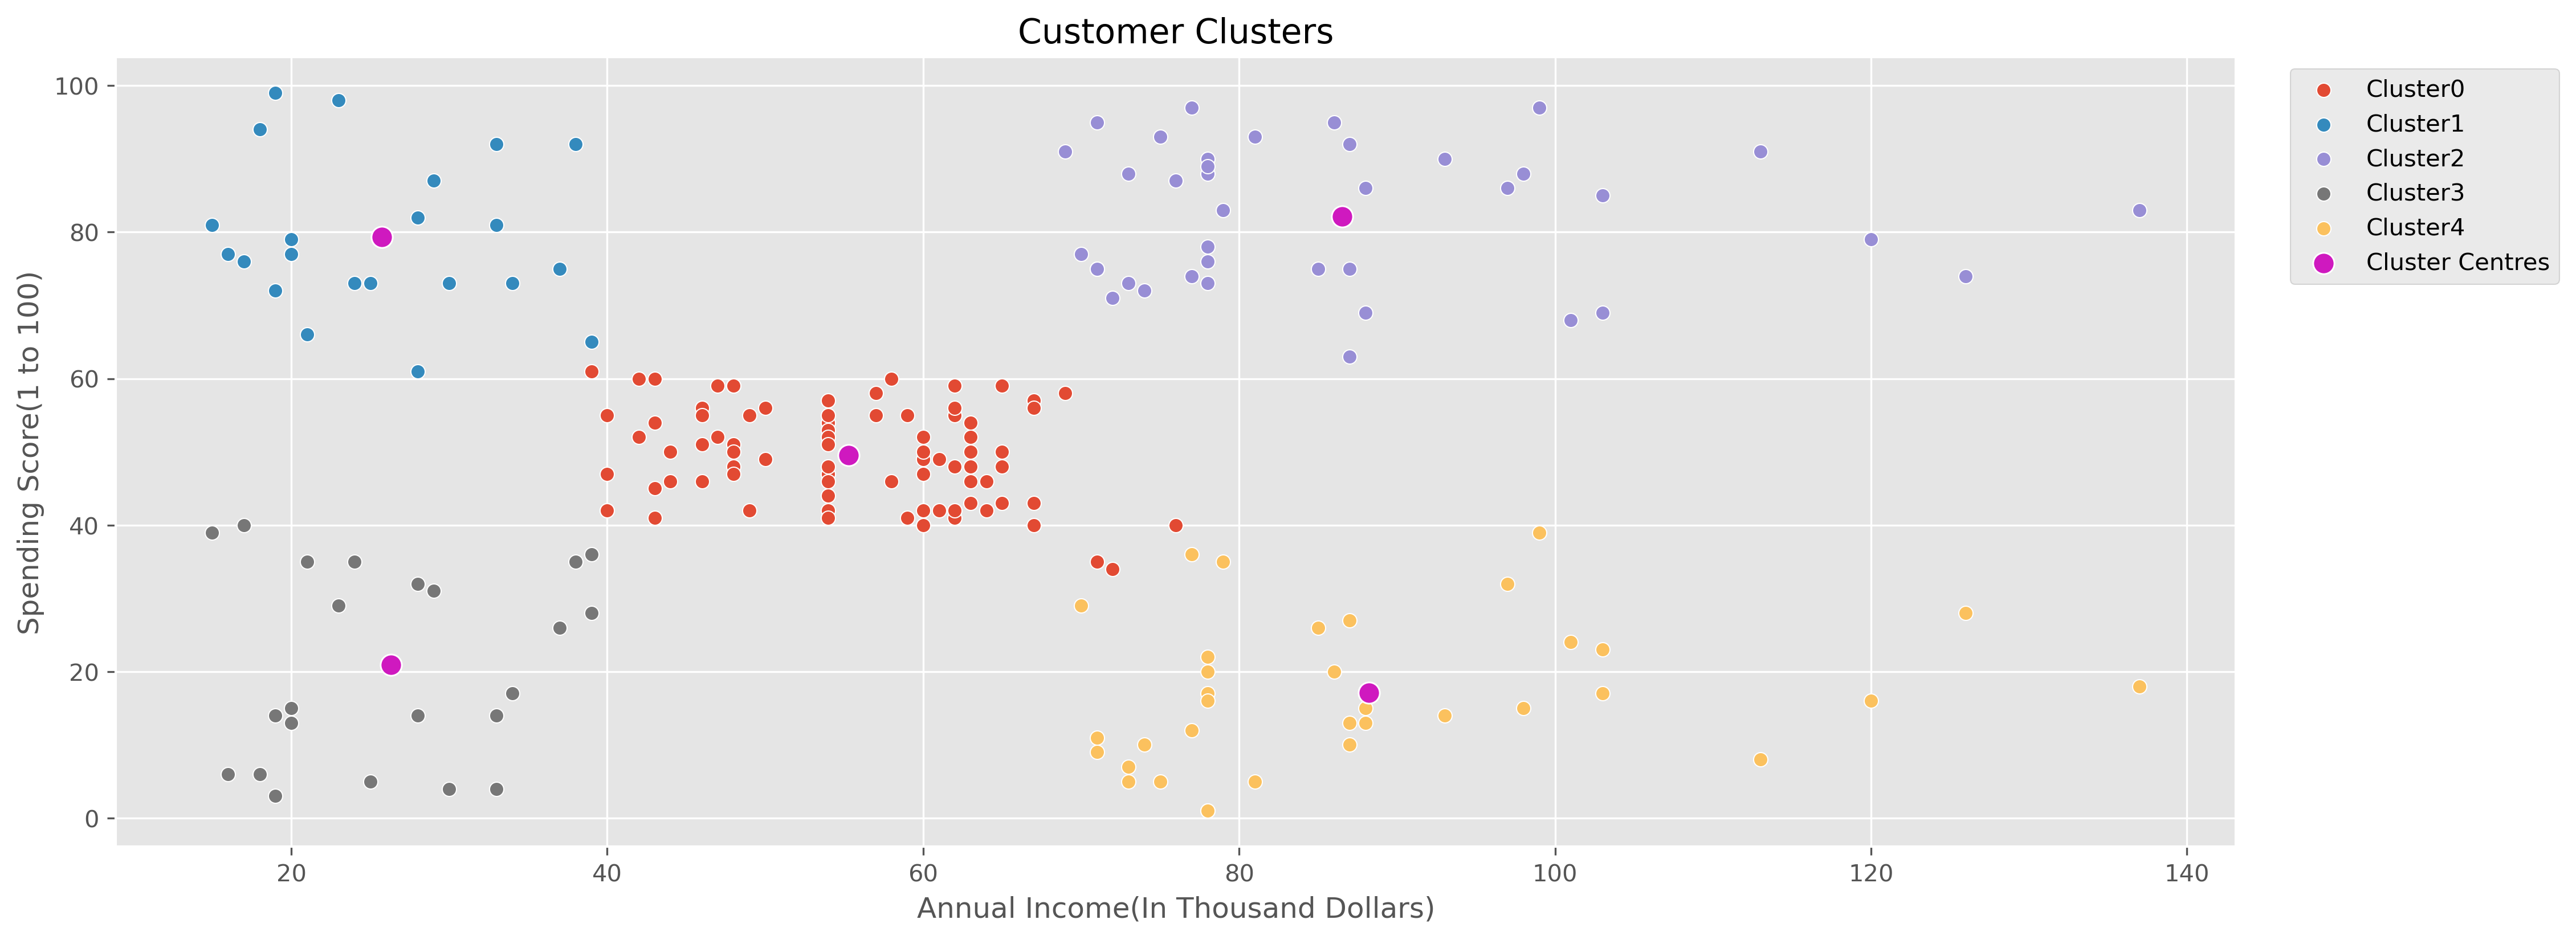

In [56]:
# Visualizing the clusters
plt.figure(figsize = (16,6), dpi = 300)
sns.scatterplot(X[y_kmeans == 0,0], X[y_kmeans == 0,1], label = 'Cluster0')
sns.scatterplot(X[y_kmeans == 1,0], X[y_kmeans == 1,1], label = 'Cluster1')
sns.scatterplot(X[y_kmeans == 2,0], X[y_kmeans == 2,1], label = 'Cluster2')
sns.scatterplot(X[y_kmeans == 3,0], X[y_kmeans == 3,1], label = 'Cluster3')
sns.scatterplot(X[y_kmeans == 4,0], X[y_kmeans == 4,1], label = 'Cluster4')

sns.scatterplot(centroids[:,0], centroids[:,1], s = 80, color = '#cf19bf', label = 'Cluster Centres')

plt.title('Customer Clusters')
plt.xlabel('Annual Income(In Thousand Dollars)')
plt.ylabel('Spending Score(1 to 100)')
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

In [57]:
# Showing clusters with customers
df['Cluster'] = y_kmeans
df.head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,1
2,3,Female,20,16,6,3
3,4,Female,23,16,77,1
4,5,Female,31,17,40,3
5,6,Female,22,17,76,1
6,7,Female,35,18,6,3
7,8,Female,23,18,94,1
8,9,Male,64,19,3,3
9,10,Female,30,19,72,1
